Problem statement: To build a CNN based model which can accurately detect melanoma. Melanoma is a type of cancer that can be deadly if not detected early. It accounts for 75% of skin cancer deaths. A solution which can evaluate images and alert the dermatologists about the presence of melanoma has the potential to reduce a lot of manual effort needed in diagnosis.

### Importing Skin Cancer Data
#### To do: Take necessary actions to read the data

### Importing all the important libraries

In [1]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import PIL
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import warnings
warnings.filterwarnings('ignore')

In [2]:
## If you are using the data by mounting the google drive, use the following :
#from google.colab import drive
#drive.mount('/content/gdrive')

##Ref:https://towardsdatascience.com/downloading-datasets-into-google-drive-via-google-colab-bcb1b30b0166

This assignment uses a dataset of about 2357 images of skin cancer types. The dataset contains 9 sub-directories in each train and test subdirectories. The 9 sub-directories contains the images of 9 skin cancer types respectively.

In [3]:
# Defining the path for train and test images
## Todo: Update the paths of the train and test dataset
#data_dir_train = pathlib.Path('/content/gdrive/MyDrive/Skin cancer dataset/Train')
#data_dir_test = pathlib.Path('/content/gdrive/MyDrive/Skin cancer dataset/Test')

In [4]:
data_dir_train = pathlib.Path('Skin cancer ISIC The International Skin Imaging Collaboration\Train')
data_dir_test = pathlib.Path('Skin cancer ISIC The International Skin Imaging Collaboration\Test')

In [10]:
image_count_train = len(list(data_dir_train.glob('*/*.jpg')))
print(image_count_train)
image_count_test = len(list(data_dir_test.glob('*/*.jpg')))
print(image_count_test)

2239
118


### Load using keras.preprocessing

Let's load these images off disk using the helpful image_dataset_from_directory utility.

### Create a dataset

Define some parameters for the loader:

In [11]:
batch_size = 32
img_height = 180
img_width = 180

Use 80% of the images for training, and 20% for validation.

In [12]:
## Write your train dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,seed=123,validation_split = 0.2,
                                                               subset = 'training',image_size=(img_height, img_width),batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


In [13]:
## Write your validation dataset here
## Note use seed=123 while creating your dataset using tf.keras.preprocessing.image_dataset_from_directory
## Note, make sure your resize your images to the size img_height*img_width, while writting the dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train,seed=123,validation_split = 0.2,
                                                               subset = 'validation',image_size=(img_height, img_width),batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


In [14]:
# List out all the classes of skin cancer and store them in a list.
# You can find the class names in the class_names attribute on these datasets.
# These correspond to the directory names in alphabetical order.
class_names = train_ds.class_names
print(class_names)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


### Visualize the data
#### Todo, create a code to visualize one instance of all the nine classes present in the dataset

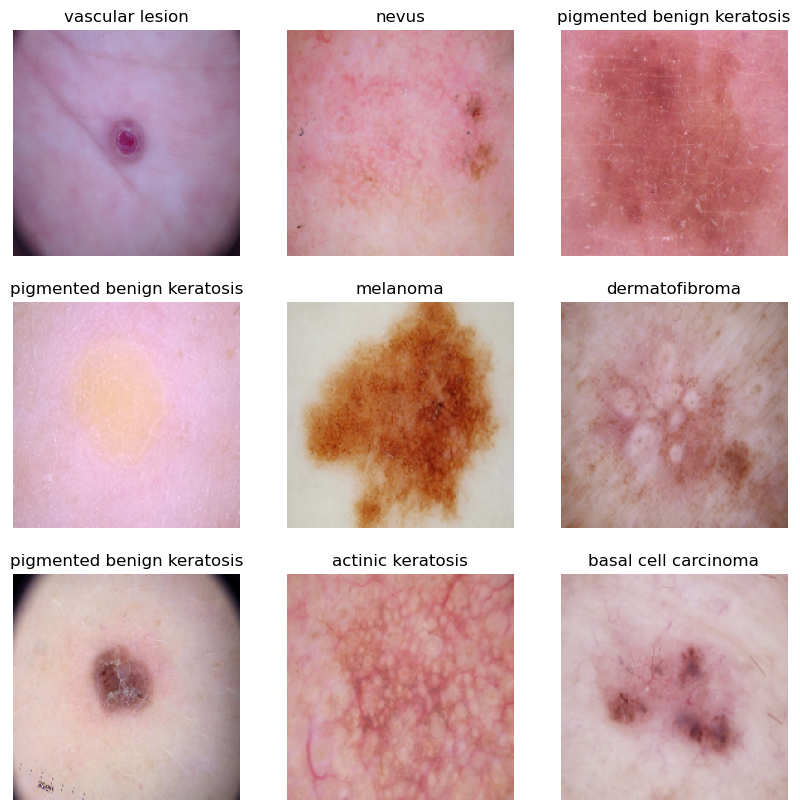

In [35]:
import matplotlib.pyplot as plt

### your code goes here, you can use training or validation data to visualize

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

The `image_batch` is a tensor of the shape `(32, 180, 180, 3)`. This is a batch of 32 images of shape `180x180x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(32,)`, these are corresponding labels to the 32 images.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [36]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Create the model
#### Todo: Create a CNN model, which can accurately detect 9 classes present in the dataset. Use ```layers.experimental.preprocessing.Rescaling``` to normalize pixel values between (0,1). The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network. Here, it is good to standardize values to be in the `[0, 1]`

In [37]:
### Your code goes here

normalization_layer = tf.keras.layers.Rescaling(1./255)
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

In [38]:
#checking the rescaled data
for images, labels in normalized_ds.take(1):
  print(images[0].numpy())
  print(images[0].numpy().shape)
  ip_shape = images[0].numpy().shape

[[[0.83250546 0.75799567 0.69917214]
  [0.833987   0.76732033 0.70457524]
  [0.8452651  0.7707553  0.71193177]
  ...
  [0.8021791  0.6894994  0.6478    ]
  [0.7989543  0.69163406 0.6484968 ]
  [0.79503274 0.68685704 0.62707037]]

 [[0.8437038  0.769194   0.71429205]
  [0.8393595  0.7687713  0.71386933]
  [0.84607846 0.77156866 0.7166667 ]
  ...
  [0.79224384 0.70518506 0.6536162 ]
  [0.7924576  0.69084966 0.6397516 ]
  [0.78109366 0.659525   0.58379495]]

 [[0.8315977  0.7531663  0.71002907]
  [0.840109   0.76952076 0.72246194]
  [0.8433189  0.76488745 0.7217502 ]
  ...
  [0.80479354 0.71851903 0.663617  ]
  [0.78834426 0.6981482  0.636928  ]
  [0.78731316 0.6777344  0.59583163]]

 ...

 [[0.8448514  0.7804361  0.7087222 ]
  [0.8424839  0.7915035  0.7248368 ]
  [0.850327   0.7993466  0.73660153]
  ...
  [0.800835   0.70944136 0.6122366 ]
  [0.789564   0.7111326  0.60525024]
  [0.7915035  0.70915055 0.5875819 ]]

 [[0.8466234  0.79446614 0.72858405]
  [0.8470589  0.8000001  0.7372549 ]


In [39]:
#creating the model

model = tf.keras.Sequential()
model.add(tf.keras.layers.Rescaling(1./255,input_shape=ip_shape))
model.add(tf.keras.layers.Conv2D(128, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Conv2D(64, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(9, activation='softmax'))

### Compile the model
Choose an appropirate optimiser and loss function for model training

In [40]:
### Todo, choose an appropirate optimiser and loss function
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(optimizer='nadam',
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [41]:
# View the summary of all layers
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_3 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 178, 178, 128)     3584      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 89, 89, 128)      0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 87, 87, 64)        73792     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 43, 43, 64)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 41, 41, 32)       

### Train the model

In [42]:
%%time
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 [==============================] - 6s 95ms/step - loss: 2.0693 - accuracy: 0.2054 - val_loss: 1.9490 - val_accuracy: 0.2796
Epoch 2/20
56/56 [==============================] - 5s 85ms/step - loss: 1.9516 - accuracy: 0.2746 - val_loss: 1.8648 - val_accuracy: 0.2819
Epoch 3/20
56/56 [==============================] - 5s 85ms/step - loss: 1.8800 - accuracy: 0.2935 - val_loss: 1.7818 - val_accuracy: 0.3311
Epoch 4/20
56/56 [==============================] - 5s 83ms/step - loss: 1.7480 - accuracy: 0.3705 - val_loss: 1.6798 - val_accuracy: 0.4273
Epoch 5/20
56/56 [==============================] - 5s 83ms/step - loss: 1.6367 - accuracy: 0.4224 - val_loss: 1.6992 - val_accuracy: 0.3848
Epoch 6/20
56/56 [==============================] - 5s 82ms/step - loss: 1.5447 - accuracy: 0.4609 - val_loss: 1.4996 - val_accuracy: 0.5011
Epoch 7/20
56/56 [==============================] - 5s 82ms/step - loss: 1.4276 - accuracy: 0.5061 - val_loss: 1.6573 - val_accuracy: 0.4609
Epoch 8/20
56

### Visualizing training results

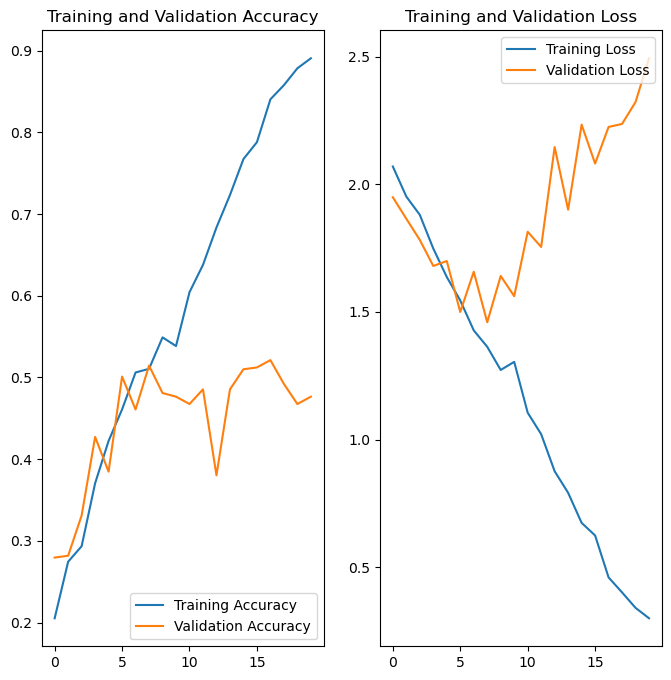

In [43]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit

### Write your findings here

The training accuracy is significantly higher than the validation accuracy, indicating overfitting.
The validation loss is also much higher than the training loss, further supporting the overfitting observation.

**Data Augmentation Strategy:**
* Since the model is overfitting, we need to introduce more variations in the training data to improve generalization.  
* We can use a combination of techniques:

1. Random Rotation: Rotate images by a small random angle.
2. Random Flipping: Flip images horizontally or vertically.
3. Random Zoom: Zoom in or out on images.
4. Random Brightness/Contrast: Adjust the brightness and contrast of images.

Along with above techniques we can also use batch normalization and drop layers to improve the fitting

In [21]:
#for supressing WARNING:tensorflow:Using a while_loop warnings
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR) 

In [13]:
# Todo, after you have analysed the model fit history for presence of underfit or overfit, choose an appropriate data augumentation strategy.
# Your code goes here
ip_shape = (180, 180, 3)
augmentation_data = keras.Sequential([
                                      tf.keras.layers.RandomFlip("horizontal", input_shape=ip_shape),
                                      tf.keras.layers.RandomRotation(0.1),
                                      tf.keras.layers.RandomZoom(0.1),
                                      tf.keras.layers.RandomContrast(0.1),
                                      tf.keras.layers.RandomBrightness(0.1)
])

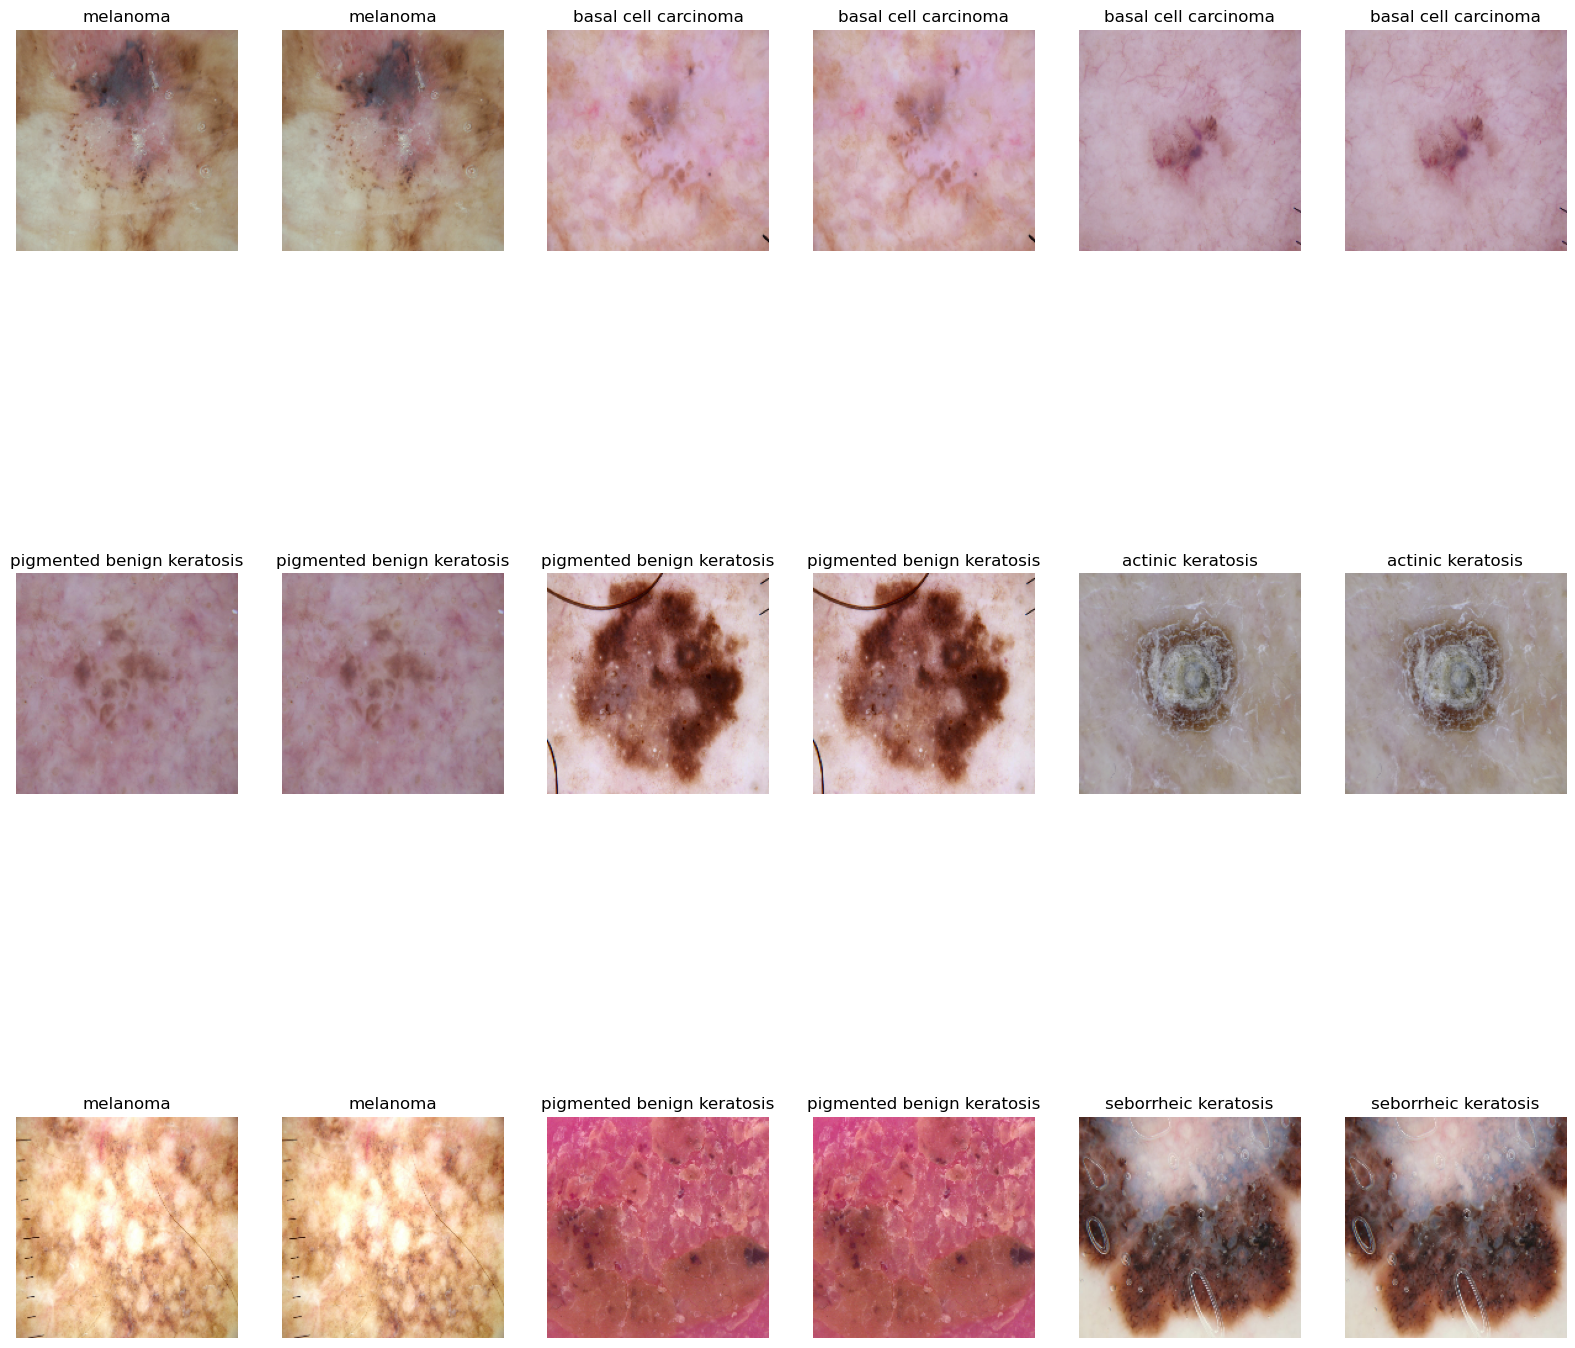

In [52]:
# Todo, visualize how your augmentation strategy works for one instance of training image.
# Your code goes here

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))
for images, labels in train_ds.take(1):
  for i in range(9):
    augmented_images = augmentation_data(images)
    ax = plt.subplot(3, 6, 2 * i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
    ax = plt.subplot(3, 6, 2 * i + 2)
    plt.imshow(augmented_images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

### Todo:
### Create the model, compile and train the model


In [58]:
## You can use Dropout layer if there is an evidence of overfitting in your findings

## Your code goes here
model = tf.keras.Sequential()
model.add(augmentation_data)
model.add(tf.keras.layers.Rescaling(1./255,input_shape=ip_shape))
model.add(tf.keras.layers.Conv2D(128, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Conv2D(64, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(9, activation='softmax'))


### Compiling the model

In [59]:
## Your code goes here
model.compile(optimizer='nadam',
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

### Training the model

In [60]:
%%time
## Your code goes here, note: train your model for 20 epochs
epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
56/56 [==============================] - 25s 377ms/step - loss: 2.0737 - accuracy: 0.1998 - val_loss: 1.9355 - val_accuracy: 0.3110
Epoch 2/20
56/56 [==============================] - 24s 421ms/step - loss: 1.9533 - accuracy: 0.2506 - val_loss: 1.8701 - val_accuracy: 0.3423
Epoch 3/20
56/56 [==============================] - 25s 443ms/step - loss: 1.9444 - accuracy: 0.2801 - val_loss: 1.8756 - val_accuracy: 0.3154
Epoch 4/20
56/56 [==============================] - 22s 401ms/step - loss: 1.8698 - accuracy: 0.3103 - val_loss: 1.7907 - val_accuracy: 0.3244
Epoch 5/20
56/56 [==============================] - 23s 414ms/step - loss: 1.7267 - accuracy: 0.3677 - val_loss: 1.6046 - val_accuracy: 0.4407
Epoch 6/20
56/56 [==============================] - 24s 436ms/step - loss: 1.6457 - accuracy: 0.4174 - val_loss: 1.8928 - val_accuracy: 0.3691
Epoch 7/20
56/56 [==============================] - 24s 434ms/step - loss: 1.5836 - accuracy: 0.4414 - val_loss: 1.4601 - val_accuracy: 0.4899

### Visualizing the results

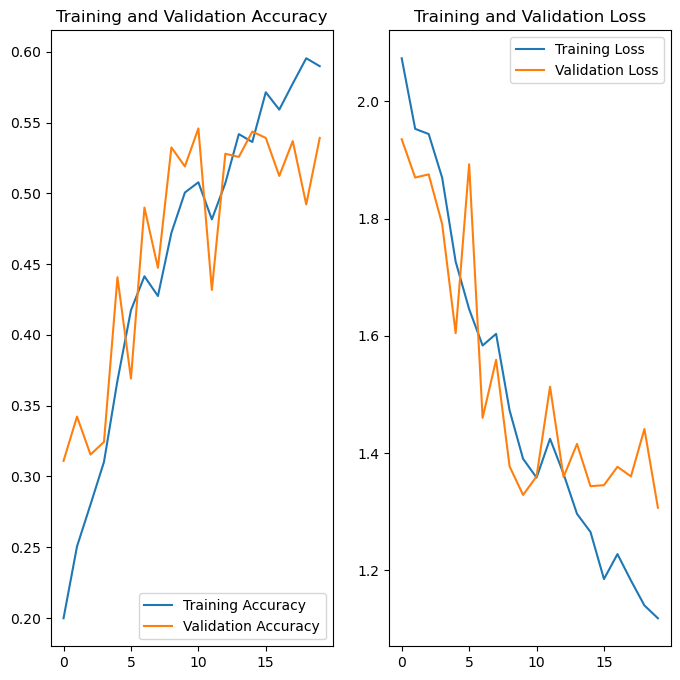

In [61]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Todo: Write your findings after the model fit, see if there is an evidence of model overfit or underfit. Do you think there is some improvement now as compared to the previous model run?

Observations:
1. We can observe that the training and validation accuracies have gone down however they are now in the same range.
2. This suggests augmentation has helped us with the overfitting problem
3. Low training and validation accuracies suggests underfitting.


#### **Todo:** Find the distribution of classes in the training dataset.
#### **Context:** Many times real life datasets can have class imbalance, one class can have proportionately higher number of samples compared to the others. Class imbalance can have a detrimental effect on the final model quality. Hence as a sanity check it becomes important to check what is the distribution of classes in the data.

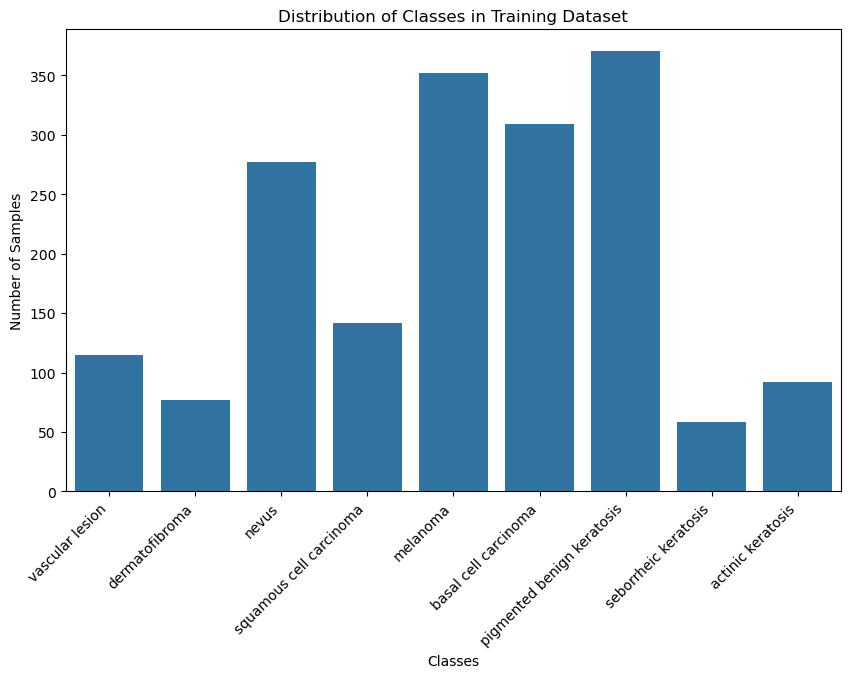

,Class,Count
0,vascular lesion,115
1,dermatofibroma,77
2,nevus,277
3,squamous cell carcinoma,142
4,melanoma,352
5,basal cell carcinoma,309
6,pigmented benign keratosis,370
7,seborrheic keratosis,58
8,actinic keratosis,92


In [63]:
# prompt: find out the number of samples per class in training data and plot the boxplot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'train_ds' is your training dataset as defined in the provided code
class_counts = {}
for images, labels in train_ds:
    for label in labels.numpy():
        class_name = class_names[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

# Convert to a Pandas DataFrame for easier plotting
df = pd.DataFrame({'Class': list(class_counts.keys()), 'Count': list(class_counts.values())})


plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=df)
plt.title('Distribution of Classes in Training Dataset')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.show()

df


In [64]:
## Your code goes here.
# Calculate the percentage of each class
df['Percentage'] = (df['Count'] / df['Count'].sum()) * 100

# Display the DataFrame with percentages
df

,Class,Count,Percentage
0,vascular lesion,115,6.417411
1,dermatofibroma,77,4.296875
2,nevus,277,15.457589
3,squamous cell carcinoma,142,7.924107
4,melanoma,352,19.642857
5,basal cell carcinoma,309,17.243304
6,pigmented benign keratosis,370,20.647321
7,seborrheic keratosis,58,3.236607
8,actinic keratosis,92,5.133929


#### **Todo:** Write your findings here:
#### - Which class has the least number of samples? - seborrheic keratosis	

#### - Which classes dominate the data in terms proportionate number of samples? pigmented benign keratosis	


#### **Todo:** Rectify the class imbalance
#### **Context:** You can use a python package known as `Augmentor` (https://augmentor.readthedocs.io/en/master/) to add more samples across all classes so that none of the classes have very few samples.

In [65]:
!pip install Augmentor

To use `Augmentor`, the following general procedure is followed:

1. Instantiate a `Pipeline` object pointing to a directory containing your initial image data set.<br>
2. Define a number of operations to perform on this data set using your `Pipeline` object.<br>
3. Execute these operations by calling the `Pipeline’s` `sample()` method.


In [68]:
path_to_training_dataset="C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin cancer ISIC The International Skin Imaging Collaboration/Train/"
import Augmentor
for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500) ## We are adding 500 samples per class to make sure that none of the classes are sparse.

Initialised with 114 image(s) found.
Output directory set to C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis\output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x15E0BD48070>: 100%|█| 500/500 [00:02<00:


Initialised with 376 image(s) found.
Output directory set to C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma\output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x15E1E692EB0>: 100%|█| 500/500 [00:02<00:


Initialised with 95 image(s) found.
Output directory set to C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin cancer ISIC The International Skin Imaging Collaboration/Train/dermatofibroma\output.

...

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x15E0BD20F40>: 100%|█| 500/500 [00:06<00


Initialised with 181 image(s) found.
Output directory set to C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x15E02C12190>: 100%|█| 500/500 [00:02<00:00, 189.83 Samples


Initialised with 139 image(s) found.
Output directory set to C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin cancer ISIC The International Skin Imaging Collaboration/Train/vascular lesion\output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x15E05C1D3D0>: 100%|█| 500/500 [00:02<00:00, 208.16 Samples


Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types.. Lets take a look at total count of augmented images.

In [78]:
image_count_train = len(list(data_dir_train.glob('*/output/*.jpg')))
print(image_count_train)

4500


In [79]:
#data_dir_train
#path_to_training_dataset = pathlib.Path(path_to_training_dataset)

### Lets see the distribution of augmented data after adding new images to the original training data.

In [80]:
#path_list = [x for x in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
#path_list

In [81]:
#lesion_list_new = [os.path.basename(os.path.dirname(os.path.dirname(y))) for y in glob(os.path.join(data_dir_train, '*','output', '*.jpg'))]
#lesion_list_new

In [ ]:
#dataframe_dict_new = dict(zip(path_list_new, lesion_list_new))

In [ ]:
#df2 = pd.DataFrame(list(dataframe_dict_new.items()),columns = ['Path','Label'])
#new_df = original_df.append(df2)

In [ ]:
#new_df['Label'].value_counts()

In [83]:
# prompt: Augmentor has stored the augmented images in the output sub-directory of each of the sub-directories of skin cancer types now add original images and augmented images from output directory to "/content/gdrive/MyDrive/Skin Cancer Dataset Augmented/Train" keep the class names in new directory as well

import shutil
import os

# Define source and destination directories
source_dirs = [f"Skin cancer ISIC The International Skin Imaging Collaboration/Train/{class_name}/output" for class_name in class_names]
destination_dir = "C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin Cancer Dataset Augmented/Train/"

# Create the destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Iterate through each class directory
for class_name in class_names:
    source_output_dir = os.path.join(path_to_training_dataset, class_name, "output")
    source_original_dir = os.path.join(path_to_training_dataset, class_name)
    destination_class_dir = os.path.join(destination_dir, class_name)
    
    # Create the destination class directory if it doesn't exist
    os.makedirs(destination_class_dir, exist_ok=True)

    # Copy original images
    for filename in os.listdir(source_original_dir):
        if filename.endswith(('.jpg', '.jpeg', '.png')):  # Adjust extensions if needed
            source_path = os.path.join(source_original_dir, filename)
            destination_path = os.path.join(destination_class_dir, filename)
            shutil.copy2(source_path, destination_path)  # copy2 preserves metadata

    # Copy augmented images
    for filename in os.listdir(source_output_dir):
        if filename.endswith(('.jpg', '.jpeg', '.png')):  # Adjust extensions if needed
            source_path = os.path.join(source_output_dir, filename)
            destination_path = os.path.join(destination_class_dir, filename)
            shutil.copy2(source_path, destination_path)  # copy2 preserves metadata

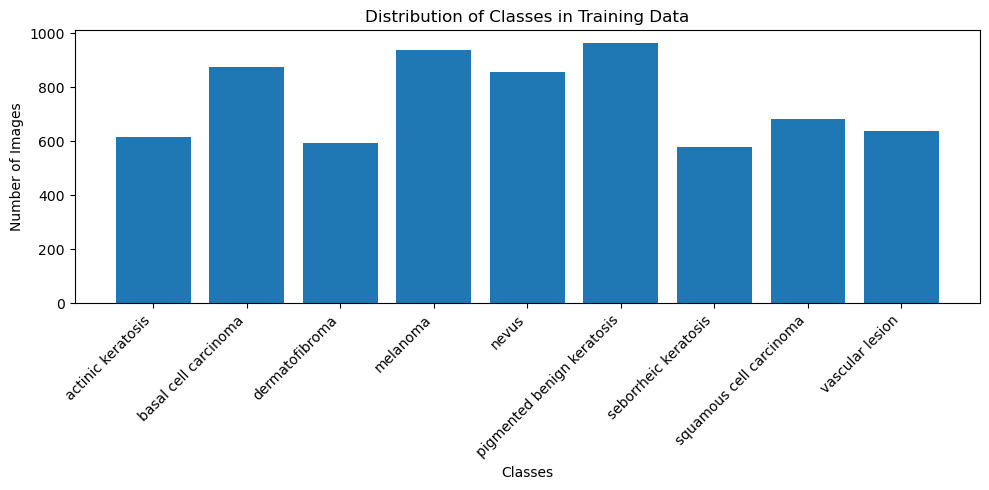

,class,count,Path
0,actinic keratosis,614,C:\Users\Swapnil\OneDrive\Upgrad course materi...
1,basal cell carcinoma,876,C:\Users\Swapnil\OneDrive\Upgrad course materi...
2,dermatofibroma,595,C:\Users\Swapnil\OneDrive\Upgrad course materi...
3,melanoma,938,C:\Users\Swapnil\OneDrive\Upgrad course materi...
4,nevus,857,C:\Users\Swapnil\OneDrive\Upgrad course materi...
5,pigmented benign keratosis,962,C:\Users\Swapnil\OneDrive\Upgrad course materi...
6,seborrheic keratosis,577,C:\Users\Swapnil\OneDrive\Upgrad course materi...
7,squamous cell carcinoma,681,C:\Users\Swapnil\OneDrive\Upgrad course materi...
8,vascular lesion,639,C:\Users\Swapnil\OneDrive\Upgrad course materi...


In [85]:
# prompt: # prompt: find out the number of samples per class in training data and plot the barplot keep the directory to image as Path in dataframe


# Assuming data_dir_train is defined as in the original code
data_dir_train_aug = pathlib.Path('C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin Cancer Dataset Augmented/Train/')

# Create a dictionary to store the counts of each class
class_counts = {}

# Iterate through the subdirectories (classes) in the training data directory
for class_dir in data_dir_train_aug.iterdir():
    if class_dir.is_dir():
        class_name = class_dir.name
        class_counts[class_name] = len(list(class_dir.glob('*.jpg')))

# Create a Pandas DataFrame from the class_counts dictionary
df2 = pd.DataFrame({'class': list(class_counts.keys()), 'count': list(class_counts.values())})
df2['Path'] = df2['class'].map(lambda x: pathlib.Path(data_dir_train_aug, x))

# Create the bar plot
plt.figure(figsize=(10, 5))
plt.bar(df2['class'], df2['count'])
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.title('Distribution of Classes in Training Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the DataFrame (optional)
df2

So, now we have added 500 images to all the classes to maintain some class balance. We can add more images as we want to improve training process.

#### **Todo**: Train the model on the data created using Augmentor

In [6]:
batch_size = 32
img_height = 180
img_width = 180

#### **Todo:** Create a training dataset

In [7]:
data_dir_train_aug = pathlib.Path('C:/Users/Swapnil/OneDrive/Upgrad course material/Melonma case study/Skin Cancer Dataset Augmented/Train/')
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train_aug,seed=123,validation_split = 0.2,
                                                               subset = 'training',image_size=(img_height, img_width),batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.


#### **Todo:** Create a validation dataset

In [8]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train_aug,seed=123,validation_split = 0.2,
                                                               subset = 'validation',image_size=(img_height, img_width),batch_size=batch_size)

Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


#### **Todo:** Create your model (make sure to include normalization)

In [97]:
## your code goes here
model = tf.keras.Sequential()
model.add(augmentation_data)
model.add(tf.keras.layers.Rescaling(1./255,input_shape=ip_shape))
model.add(tf.keras.layers.Conv2D(128, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(64, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(9, activation='softmax'))

#### **Todo:** Compile your model (Choose optimizer and loss function appropriately)

In [101]:
## your code goes here
model.compile(optimizer='nadam',
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [102]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_5 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_8 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_18 (Conv2D)          (None, 178, 178, 128)     3584      
                                                                 
 max_pooling2d_18 (MaxPoolin  (None, 89, 89, 128)      0         
 g2D)                                                            
                                                                 
 batch_normalization_3 (Batc  (None, 89, 89, 128)      512       
 hNormalization)                                                 
                                                                 
 conv2d_19 (Conv2D)          (None, 87, 87, 64)       

#### **Todo:**  Train your model

In [103]:
%%time
epochs = 30
## Your code goes here, use 50 epochs.
history = history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/30
169/169 [==============================] - 83s 466ms/step - loss: 2.5681 - accuracy: 0.3574 - val_loss: 3.5967 - val_accuracy: 0.1730
Epoch 2/30
169/169 [==============================] - 82s 483ms/step - loss: 1.6136 - accuracy: 0.4787 - val_loss: 7.4332 - val_accuracy: 0.0883
Epoch 3/30
169/169 [==============================] - 82s 486ms/step - loss: 1.3257 - accuracy: 0.5328 - val_loss: 1.9898 - val_accuracy: 0.3474
Epoch 4/30
169/169 [==============================] - 85s 500ms/step - loss: 1.1413 - accuracy: 0.5898 - val_loss: 2.8210 - val_accuracy: 0.3103
Epoch 5/30
169/169 [==============================] - 89s 524ms/step - loss: 1.0404 - accuracy: 0.6204 - val_loss: 1.8094 - val_accuracy: 0.4410
Epoch 6/30
169/169 [==============================] - 89s 523ms/step - loss: 0.9372 - accuracy: 0.6428 - val_loss: 1.8724 - val_accuracy: 0.4417
Epoch 7/30
169/169 [==============================] - 87s 514ms/step - loss: 0.9234 - accuracy: 0.6575 - val_loss: 1.9665 - val_ac

#### **Todo:**  Visualize the model results

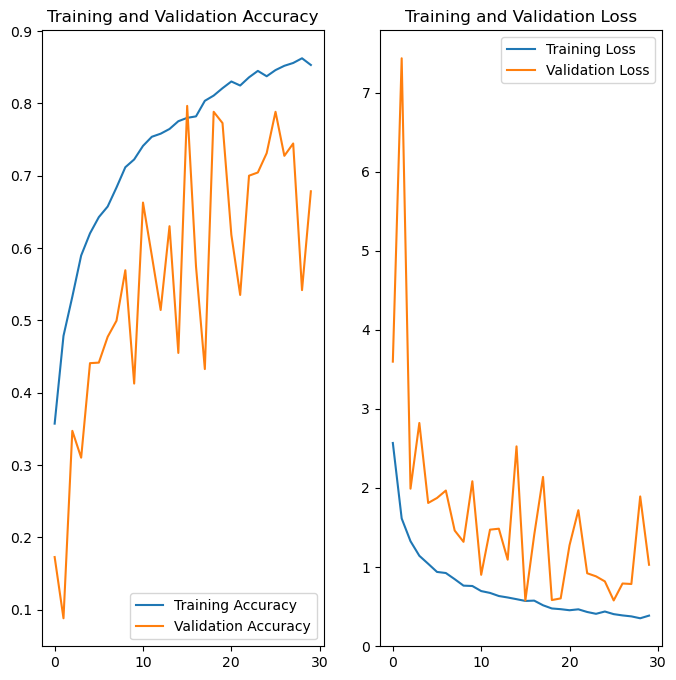

In [104]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [105]:
model.save('CNN_3_Conv_BN+Drop_model_local.keras')

#### **Todo:**  Analyze your results here. Did you get rid of underfitting/overfitting? Did class rebalance help?

We can observe that the accuracies have increased after using augmentation, batch normalization however still the validation accuracy is lower than training accuracy.

We can try adding/ subtracting the layers, modifying the architecture to get better result.

In [45]:
ip_shape = (180, 180, 3)

In [51]:
#Model with Batch Normalization
model = tf.keras.Sequential()
model.add(augmentation_data)
model.add(tf.keras.layers.Rescaling(1./255,input_shape=ip_shape))
model.add(tf.keras.layers.Conv2D(128, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.Conv2D(128, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2, 2)))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(64, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.Conv2D(64, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2, 2)))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2, 2)))

model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(9, activation='softmax'))

In [52]:
## your code goes here
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
#compiling the model
from tensorflow.keras.losses import SparseCategoricalCrossentropy
model.compile(optimizer='nadam',
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# ModelCheckpoint callback is employed alongside the model.fit() training process to periodically save the model
# or its weights (in a checkpoint file)
checkpoint = ModelCheckpoint("CNN_6_Conv2D + 3_BN_local.keras", monitor="val_accuracy", save_best_only=True, mode="auto", verbose=1)

# Early stop the training when a monitored metric ceases to show improvement
earlystop = EarlyStopping(monitor="val_accuracy", patience=5, mode="auto", verbose=1)



In [53]:
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_9 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_37 (Conv2D)          (None, 180, 180, 128)     3584      
                                                                 
 conv2d_38 (Conv2D)          (None, 180, 180, 128)     147584    
                                                                 
 max_pooling2d_23 (MaxPoolin  (None, 90, 90, 128)      0         
 g2D)                                                            
                                                                 
 batch_normalization_15 (Bat  (None, 90, 90, 128)      512       
 chNormalization)                                    

#### Training the model

In [54]:
%%time


epochs = 50
## Your code goes here, use 50 epochs.
history = history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[checkpoint, earlystop]
)

Epoch 1/50
169/169 [==============================] - ETA: 0s - loss: 1.8859 - accuracy: 0.3301
Epoch 1: val_accuracy improved from -inf to 0.07572, saving model to model.keras
169/169 [==============================] - 92s 518ms/step - loss: 1.8859 - accuracy: 0.3301 - val_loss: 2.8032 - val_accuracy: 0.0757
Epoch 2/50
169/169 [==============================] - ETA: 0s - loss: 1.4967 - accuracy: 0.4369
Epoch 2: val_accuracy improved from 0.07572 to 0.19896, saving model to model.keras
169/169 [==============================] - 87s 515ms/step - loss: 1.4967 - accuracy: 0.4369 - val_loss: 2.3960 - val_accuracy: 0.1990
Epoch 3/50
169/169 [==============================] - ETA: 0s - loss: 1.3404 - accuracy: 0.4928
Epoch 3: val_accuracy improved from 0.19896 to 0.32294, saving model to model.keras
169/169 [==============================] - 88s 517ms/step - loss: 1.3404 - accuracy: 0.4928 - val_loss: 2.2567 - val_accuracy: 0.3229
Epoch 4/50
169/169 [==============================] - ETA: 0s

#### Visualizing the model performance

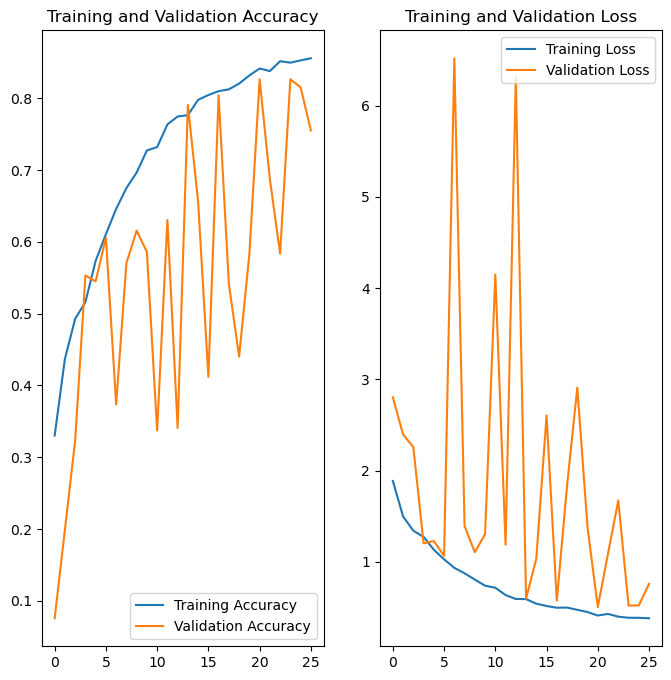

In [56]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Observations:
1. We can observe that by altering the architecture has increased the accuracy of the model.
2. The training accuracy: 0.8412 and val_accuracy: 0.8263 is big improvement over earlier models.
3. We can improve the model further by changing the hyperparameters or adding one more Conv layer.
4. In this model no dropout layers are used suggesting batch normalization alone is enough to handle the overfitting issue.
5. However we can observe that there is huge variance between validation accuracy.


### Another model 

In [57]:
#Model with Batch Normalization
model = tf.keras.Sequential()
model.add(augmentation_data)
model.add(tf.keras.layers.Rescaling(1./255,input_shape=ip_shape))
model.add(tf.keras.layers.Conv2D(128, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.Conv2D(128, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2, 2)))
model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(64, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.Conv2D(64, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2, 2)))
model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.Conv2D(32, 3, activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2), strides=(2, 2)))
model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(9, activation='softmax'))

In [61]:
## your code goes here
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
#compiling the model
from tensorflow.keras.losses import SparseCategoricalCrossentropy
model.compile(optimizer='nadam',
              loss=SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# ModelCheckpoint callback is employed alongside the model.fit() training process to periodically save the model
# or its weights (in a checkpoint file)
checkpoint = ModelCheckpoint("CNN_6_Con2D + 3 BN + 3_Drop_local.keras", monitor="val_accuracy", save_best_only=True, mode="auto", verbose=1)

# Early stop the training when a monitored metric ceases to show improvement
earlystop = EarlyStopping(monitor="val_accuracy", patience=10, mode="auto", verbose=1)



In [62]:
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_10 (Rescaling)    (None, 180, 180, 3)       0         
                                                                 
 conv2d_43 (Conv2D)          (None, 180, 180, 128)     3584      
                                                                 
 conv2d_44 (Conv2D)          (None, 180, 180, 128)     147584    
                                                                 
 max_pooling2d_26 (MaxPoolin  (None, 90, 90, 128)      0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 90, 90, 128)       0         
                                                     

#### Training the model

In [60]:
%%time

epochs = 50
## Your code goes here, use 50 epochs.
history = history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[checkpoint, earlystop]
)

Epoch 1/50
169/169 [==============================] - ETA: 0s - loss: 1.8567 - accuracy: 0.3331
Epoch 1: val_accuracy improved from -inf to 0.14031, saving model to CNN_6_Con2D + 3 BN + 3_Drop_local.keras
169/169 [==============================] - 92s 520ms/step - loss: 1.8567 - accuracy: 0.3331 - val_loss: 2.6350 - val_accuracy: 0.1403
Epoch 2/50
169/169 [==============================] - ETA: 0s - loss: 1.5174 - accuracy: 0.4212
Epoch 2: val_accuracy improved from 0.14031 to 0.19079, saving model to CNN_6_Con2D + 3 BN + 3_Drop_local.keras
169/169 [==============================] - 89s 525ms/step - loss: 1.5174 - accuracy: 0.4212 - val_loss: 3.5361 - val_accuracy: 0.1908
Epoch 3/50
169/169 [==============================] - ETA: 0s - loss: 1.3888 - accuracy: 0.4659
Epoch 3: val_accuracy improved from 0.19079 to 0.19302, saving model to CNN_6_Con2D + 3 BN + 3_Drop_local.keras
169/169 [==============================] - 88s 522ms/step - loss: 1.3888 - accuracy: 0.4659 - val_loss: 3.6880 

#### Visualizing the model performance

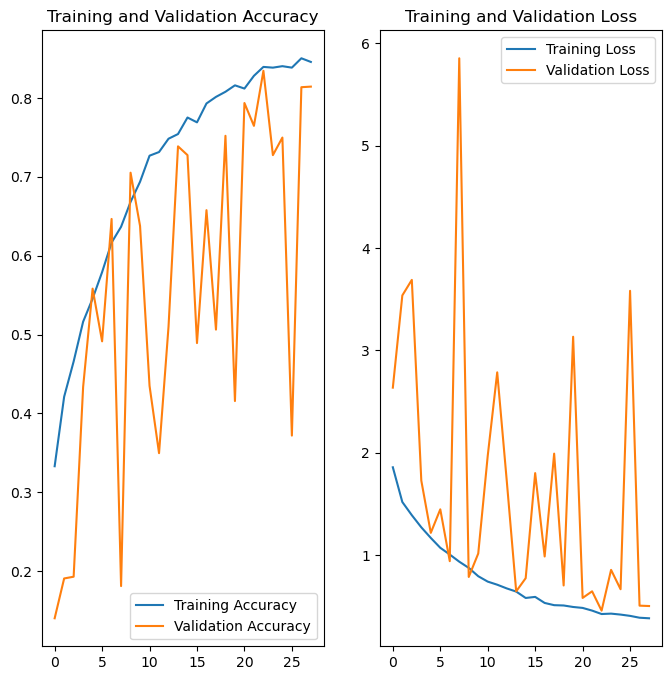

In [63]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Observations:
1. We can observe that by altering the architecture has increased the accuracy of the model.
2. The training accuracy: 0.8394 and  val_accuracy: 0.8344 is improvement over earlier models.
3. We can improve the model further by changing the hyperparameters or adding one more Conv layer.
4. However we can observe that there is huge variance between validation accuracy.


In [22]:
# for importing the model
from keras.models import load_model
model = load_model('CNN_6_Conv2D + 3_BN_local.keras') 
model_2 = load_model('CNN_6_Con2D + 3 BN + 3_Drop_local.keras')

### Model Evaluation

Skin cancer ISIC The International Skin Imaging Collaboration\Test\basal cell carcinoma\*
1/1 [==============================] - 0s 15ms/step
Model 1 - Actual Class: basal cell carcinoma
Predicted Class: basal cell carcinoma
1/1 [==============================] - 0s 15ms/step
Model 2 - Actual Class: basal cell carcinoma
Predicted Class: basal cell carcinoma


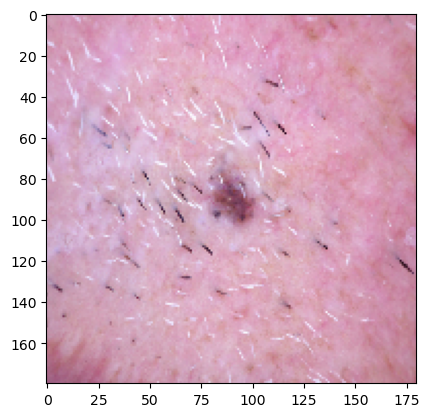

In [33]:
# Evaluating our model on one of the instances in the test set

from tensorflow.keras.preprocessing.image import load_img
import glob

image_path_test = os.path.join(data_dir_test, class_names[1], '*')
print(image_path_test)
test_image = glob.glob(image_path_test)
test_image = load_img(test_image[5], target_size=(180, 180, 3))
plt.imshow(test_image)
plt.grid(False)

img = np.expand_dims(test_image, axis=0)
predicted = model.predict(img)
predicted = np.argmax(predicted)
predicted_class = class_names[predicted]
print("Model 1 - Actual Class: " + class_names[1] +'\n'+ "Predicted Class: " + predicted_class)

predicted = model_2.predict(img)
predicted = np.argmax(predicted)
predicted_class = class_names[predicted]
print("Model 2 - Actual Class: " + class_names[1] +'\n'+ "Predicted Class: " + predicted_class)